## Data & Preprocessing

In [1]:
AXIS_CHANNELS = {
    "x": [0, 3, 6, 9, 12, 15],
    "y": [1, 4, 7, 10, 13, 16],
    "z": [2, 5, 8, 11, 14, 17]
}

SIGNAL_CHANNELS = {
    "accelerometer": [0, 1, 2],
    "gravity": [3, 4, 5],
    "gyros": [6, 7, 8],
    "lin_accel": [9, 10, 11],
    "game_rot_vec": [12, 13, 14],
    "magn_field": [15, 16, 17]
}

## XROCKET Encoder & Predictions

In [2]:
import sys
import ast
import numpy as np

from pathlib import Path
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import f_classif

from torch import Tensor, concat
from utils import input_generation, dilation_combinations, channel_combinations


# generate combinations of channels
ablation_experiments = {"baseline": None, **channel_combinations(AXIS_CHANNELS), **channel_combinations(SIGNAL_CHANNELS)}

results = []

#------------------------------
# SIGNAL EXPERIMENTS (TASK 1.1)
#------------------------------
for experiment, channels_to_remove in ablation_experiments.items():

    X, y, channel_names = input_generation(Path("KSAS-Dataset/movements"), channels_to_remove)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    #-----------------
    # X-ROCKET ENCODER
    #-----------------
    repo_path = str(Path.cwd() / "xrocket")
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    from xrocket.encoder import XRocket

    encoder = XRocket(in_channels=len(channel_names), max_kernel_span=33, combination_order=1, feature_cap=10_000, kernel_length=9, max_dilations=32)
    encoder.fit(Tensor(X_train[0]).unsqueeze(0))


    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    embed_train, embed_test = [], []

    for x in X_train:
        embed_train.append(encoder(Tensor(x).unsqueeze(0)))

    for x in X_test:
        embed_test.append(encoder(Tensor(x).unsqueeze(0)))


    feature_names = pd.Index(encoder.feature_names).rename(["pattern", "dilation", "channel", "threshold"])
    embed_train = pd.DataFrame(data=concat(embed_train), columns=feature_names)
    embed_test = pd.DataFrame(data=concat(embed_test), columns=feature_names)


    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    #----------------------------------
    # DILATION EXPERIMENTS (TASK 1.2)
    #----------------------------------
    if channels_to_remove is None:

        dilation_results = []

        # Baseline with all dilations
        dilation_experiments = {"baseline": None, **dilation_combinations(list(encoder.dilations))}

        for name, dilation in dilation_experiments.items():

            if dilation is None:
                train_dilation = embed_train
                test_dilation = embed_test

            else:
                # Remove features belonging to these dilations
                dilation_mask = ~embed_train.columns.get_level_values("dilation").isin(dilation)

                train_dilation = embed_train.loc[:, dilation_mask]
                test_dilation = embed_test.loc[:, dilation_mask]


            #-----------------------
            # PREDICTIONS (TASK 1.2)
            #-----------------------
            dilation_model = RandomForestClassifier(random_state=42)
            dilation_model.fit(train_dilation, y_train)

            dilation_pred = dilation_model.predict(test_dilation)
            dilation_accuracy = accuracy_score(y_test, dilation_pred)

            dilation_results.append({
                "experiment": name,
                "removed_dilations": dilation,
                "remaining_features": train_dilation.shape[1],
                "accuracy": dilation_accuracy
            })


    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    #-----------------------
    # PREDICTIONS (TASK 1.1)
    #-----------------------
    model = RandomForestClassifier(random_state=42)
    model.fit(embed_train, y_train)

    pred_test = model.predict(embed_test)
    acc_test = accuracy_score(y_test, pred_test)


    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    #--------------------------------
    # PATTERN ANALYSIS (TASK 1.3)
    #--------------------------------
    if channels_to_remove is None:

        pattern_results = []

        # Analyze each movement against all the others
        for movement in sorted(set(y_train)):

            # One-vs-rest labels
            y_binary = (y_train == movement).astype(int)

            # ANOVA F-score for every XROCKET feature
            f_scores, p_values = f_classif(embed_train, y_binary)

            # Select the 20 most discriminative patterns for this movement
            top_feature_positions = np.argsort(f_scores)[::-1][:20]

            for position in top_feature_positions:

                # Decode channel
                channel_vector = ast.literal_eval(embed_train.columns[position][2])
                channel_index = int(np.argmax(channel_vector))
                channel = channel_names[channel_index]

                # Mean activation for the movement and for all the other movements
                movement_mean = embed_train.iloc[y_binary == 1, position].mean()
                rest_mean = embed_train.iloc[y_binary == 0, position].mean()

                pattern_results.append({
                    "movement": movement,
                    "feature_position": position,
                    "pattern": embed_train.columns[position][0],
                    "dilation": embed_train.columns[position][1],
                    "channel": channel,
                    "threshold": embed_train.columns[position][3],
                    "f_score": f_scores[position],
                    "p_value": p_values[position],
                    "movement_mean": movement_mean,
                    "rest_mean": rest_mean
                })


        pattern_results_df = pd.DataFrame(pattern_results)

        Path("results").mkdir(exist_ok=True)
        pattern_results_df.to_csv("results/task_1_3_patterns.csv", index=False)

        print(pattern_results_df)


    #-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

    # Accuracy for each movement (Task 1.1)
    for movement in sorted(set(y_test)):

        mask = y_test == movement

        movement_accuracy = accuracy_score(y_test[mask], pred_test[mask])

        results.append({
            "experiment": experiment,
            "removed_channels": 0 if channels_to_remove is None else len(channels_to_remove),
            "remaining_channels": len(channel_names),
            "movement": movement,
            "accuracy": movement_accuracy
        })

     movement  feature_position  \
0           0              2172   
1           0              3689   
2           0              2459   
3           0              4009   
4           0              3692   
..        ...               ...   
115         5              5033   
116         5              4919   
117         5              3408   
118         5              4906   
119         5              3423   

                                               pattern  dilation  \
0    [-1.0, -1.0, -1.0, 2.0, -1.0, -1.0, 2.0, -1.0,...         2   
1    [-1.0, -1.0, -1.0, -1.0, 2.0, -1.0, 2.0, 2.0, ...         3   
2    [2.0, -1.0, -1.0, -1.0, -1.0, 2.0, -1.0, 2.0, ...         2   
3    [-1.0, -1.0, 2.0, -1.0, -1.0, -1.0, 2.0, 2.0, ...         3   
4    [-1.0, -1.0, -1.0, -1.0, -1.0, 2.0, 2.0, 2.0, ...         3   
..                                                 ...       ...   
115  [-1.0, -1.0, -1.0, -1.0, 2.0, -1.0, 2.0, 2.0, ...         4   
116  [-1.0, 2.0, -1.0, -1.0, -1.0, 

## RESULTS VISUALIZATION

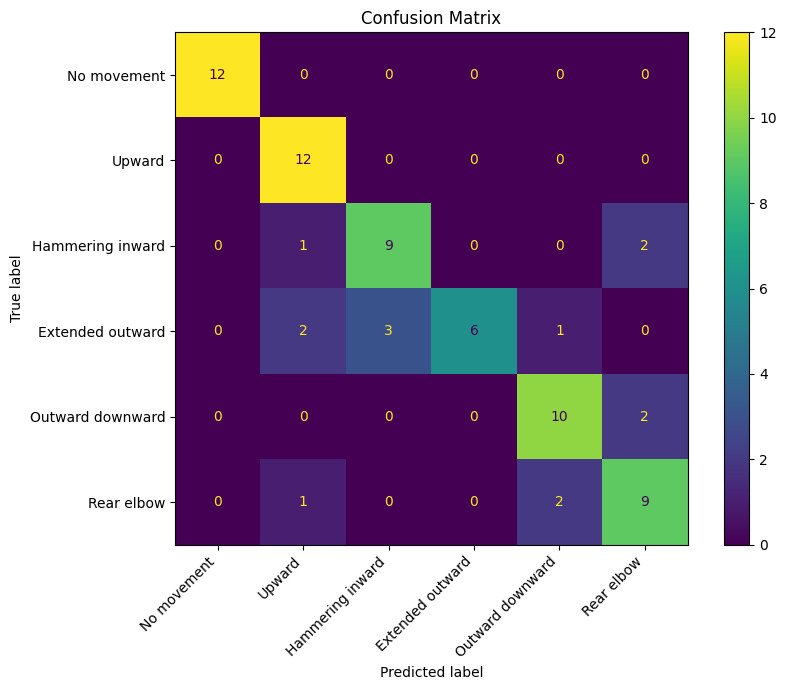

In [3]:
import matplotlib.pyplot as plt


movement_names = [
    "No movement",
    "Upward",
    "Hammering inward",
    "Extended outward",
    "Outward downward",
    "Rear elbow"
]

cm = confusion_matrix(y_test, pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=movement_names)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="viridis", values_format="d", colorbar=True)

plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Task 1.1

In [4]:
results_df = pd.DataFrame(results)

accuracy_table = results_df.pivot(index="experiment", columns="movement", values="accuracy")

# delta table -> variation of accuracy
baseline = accuracy_table.loc["baseline"]

delta_table = accuracy_table.subtract(baseline, axis=1)

delta_table = delta_table.drop("baseline")
delta_table.to_csv("experimental_results/task_1_1_accuracy.csv")

delta_table


movement,0,1,2,3,4,5
experiment,,,,,,
remove_accelerometer,0.0,0.000000,0.000000,-0.166667,0.000000,-0.083333
remove_accelerometer_game_rot_vec,0.0,0.083333,0.083333,-0.166667,0.000000,0.000000
remove_accelerometer_game_rot_vec_magn_field,0.0,0.083333,0.000000,-0.166667,0.000000,0.000000
remove_accelerometer_gravity,0.0,0.000000,-0.333333,-0.250000,0.000000,0.000000
remove_accelerometer_gravity_game_rot_vec,0.0,0.083333,-0.166667,-0.333333,0.000000,0.000000
...,...,...,...,...,...,...
remove_x_y,0.0,0.083333,-0.083333,0.000000,-0.250000,-0.166667
remove_x_z,0.0,0.000000,-0.083333,-0.333333,0.000000,0.000000
remove_y,0.0,0.083333,0.000000,-0.166667,-0.166667,-0.083333


# Task 1.2

In [5]:
dilation_results_df = pd.DataFrame(dilation_results)

# Use experiment names as index
accuracy_table = dilation_results_df.set_index("experiment")

# Baseline accuracy
baseline = accuracy_table.loc["baseline", "accuracy"]

# Accuracy difference from baseline
accuracy_table["delta_accuracy"] = (
    accuracy_table["accuracy"] - baseline
)

accuracy_table.to_csv("experimental_results/task_1_2_accuracy.csv")

accuracy_table

,removed_dilations,remaining_features,accuracy,delta_accuracy
experiment,,,,
baseline,None,6048,0.875000,0.000000
remove_1,[1],4536,0.819444,-0.055556
remove_2,[2],4536,0.833333,-0.041667
remove_3,[3],4536,0.847222,-0.027778
remove_4,[4],4536,0.819444,-0.055556
remove_1_2,"[1, 2]",3024,0.805556,-0.069444
remove_1_3,"[1, 3]",3024,0.847222,-0.027778
remove_1_4,"[1, 4]",3024,0.847222,-0.027778
remove_2_3,"[2, 3]",3024,0.847222,-0.027778


# Task 1.3

In [7]:
pattern_table = (pattern_results_df[["movement", "feature_position", "channel", "dilation", "f_score", "p_value", "movement_mean", "rest_mean"]].sort_values(["movement", "f_score"], ascending=[True, False]).reset_index(drop=True))

pattern_table.to_csv("experimental_results/task_1_3_discriminative_patterns.csv", index=False)

pattern_table

,movement,feature_position,channel,dilation,f_score,p_value,movement_mean,rest_mean
0,0,2172,game_rot_vec_x,2,338.962293,5.956721e-42,0.148847,0.487774
1,0,3689,magn_field_z,3,310.347489,7.659263e-40,0.130559,0.496714
2,0,2459,lin_accel_z,2,308.352654,1.086272e-39,0.213000,0.491592
3,0,4009,game_rot_vec_y,3,304.695463,2.069293e-39,0.149657,0.464226
4,0,3692,accelerometer_z,3,300.920039,4.046278e-39,0.129061,0.496973
...,...,...,...,...,...,...,...,...
115,5,5033,lin_accel_z,4,68.415024,4.099824e-14,0.463571,0.188136
116,5,4919,gravity_z,4,66.117164,9.395733e-14,0.560196,0.323850
117,5,3408,gyros_x,3,66.079278,9.525770e-14,0.511798,0.285469
118,5,4906,lin_accel_y,4,65.575702,1.143782e-13,0.269017,0.510837
